In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
def loglike_line(params, time, dms, dm_errs):
    """
    Full Gaussian log-likelihood for DM(t) = m*t + b with known errors dm_errs.
    
    params = (m, b)
    time, dms, dm_errs (uncertainty) must be numpy arrays of same length.
    """
    m, b = params
    model = np.add(np.multiply(m,time) ,b)
    resid = dms - model
    
    # full log-likelihood including normalization
    ll = -0.5 * np.sum(
        np.log(2 * np.pi * np.power(dm_errs,2)) +
        (np.power(resid,2)) / (np.power(dm_errs,2))
    )
    return ll

def loglike_constant(params, dms, dm_errs):
    """
    Full Gaussian log-likelihood for constant model DM(t) = m
    with known errors dm_errs.

    params = (m,)  # a 1-element tuple or list
    DM, DM_errs must be numpy arrays of the same length.
    """
    m = params
    resid = dms - m
    
    ll = -0.5 * np.sum(
        np.log(2 * np.pi * dm_errs**2) +
        (resid**2) / (dm_errs**2)
    )
    return ll

def bic(loglike, k, n):
    """
    Bayesian Information Criterion.
    loglike = maximum log-likelihood
    k = number of model parameters
    n = number of data points
    """
    return k * np.log(n) - 2 * loglike

def mle_constant(dm, dm_errs):
    w = 1 / np.power(dm_errs,2)
    m = np.sum(w * dm) / np.sum(w)
    return m

def mle_line(time, dm, dm_errs):
    w = 1 / np.power(dm_errs,2)
    
    S   = np.sum(w)
    Sx  = np.sum(w * time)
    Sy  = np.sum(w * dm)
    Sxx = np.sum(w * time * time)
    Sxy = np.sum(w * time * dm)

    Delta = S * Sxx - Sx**2

    m = (S * Sxy - Sx * Sy) / Delta
    b = (Sxx * Sy - Sx * Sxy) / Delta

    return m, b

In [12]:
def choose_model(time, dms, dm_errs, plot=True):
    m_line, b_line = mle_line(time, dms, dm_errs)
    m_const = mle_constant(dms, dm_errs)
    ll_line = loglike_line([m_line, b_line], time, dms, dm_errs)
    ll_const = loglike_constant(m_const, dms, dm_errs)
    bic_line = bic(ll_line, 2, len(time))
    bic_const = bic(ll_const, 1, len(time))
    if plot:
        plt.figure()
        plt.errorbar(time, dms, dm_errs, fmt='.', capsize=3, color='k', label='Burst detections')
        print('line bic:' + str(bic_line))
        print('constant: ' + str(bic_const))
        plt.ylabel('DM')
        plt.xlabel('Time (MJD)')
        if (bic_line - bic_const) < -10: 
            print('changing DM prefered. params: ')
            print(m_line, b_line) 
            plt.plot(np.linspace(min(time), max(time),100), m_line*np.linspace(min(time), max(time),100)+b_line, color='r', label='Linear model (preferred)')
            plt.axhline(m_const, color='grey', linestyle='--', label='Constant model')
        else:  
            print('constant DM prefered. params:')
            print(m_const)
            plt.axhline(m_const, color='r', label='Constant model (preferred)')
            plt.plot(np.linspace(min(time), max(time),100), m_line*np.linspace(min(time), max(time),100)+b_line,linestyle='--', color='grey',label='Linear model')
        plt.ylim(min(dms)- max(dm_errs), max(dms)+ max(dm_errs))
        plt.legend()
    return bic_line

In [13]:
omar_sorted = np.array([
[60380.27609,528.085,0.508],
[60380.43194,527.830,0.102],
[60380.45214,528.146,0.160],
[60383.26844,528.205,0.260],
[60386.37677,527.854,0.075],
[60431.43777,528.007,0.240],
[60573.92099,528.313,0.103],
[60581.87250,528.464,0.086],
[60586.95299,528.468,0.081],
[60673.60990,528.761,0.406],
[60674.67263,528.904,0.139],
[60686.62063,528.746,0.471],
[60698.53842,528.673,0.560]
])
omar_data = np.transpose(omar_sorted)

line bic:-6.0667276118099815
constant: 68.70342408354504
changing DM prefered. params: 
0.002903645177469987 352.55338824859314


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:59<00:00, 16846.01it/s]


0.002727
R147 IS SIGNIFICANT


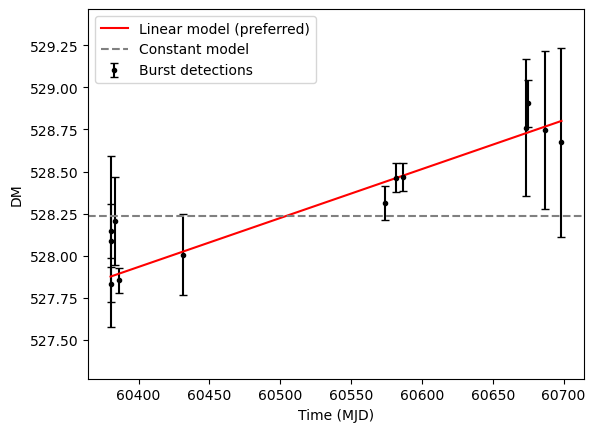

In [14]:
N_sims = 1e6
dms_random = np.random.normal(loc = np.mean(omar_data[1]), scale= np.sqrt(np.var(omar_data[1])), size = [int(N_sims),len(omar_data[0])])
sim_bic = np.zeros(int(N_sims))
real_bic = choose_model(omar_data[0], omar_data[1],omar_data[2], plot=True)
for i in tqdm(range(int(N_sims))):
    sim_bic[i] = choose_model(omar_data[0], dms_random[i], omar_data[2], plot=False)
print(np.sum(sim_bic < real_bic)/N_sims)
if np.sum(sim_bic < real_bic)/N_sims < (0.05):
    print('R147 IS SIGNIFICANT') 

In [1]:
from scipy import stats

p = 0.002727
sigma = stats.norm.isf(p)
print(sigma)  # → ~2.78σ

2.7789197341897203
